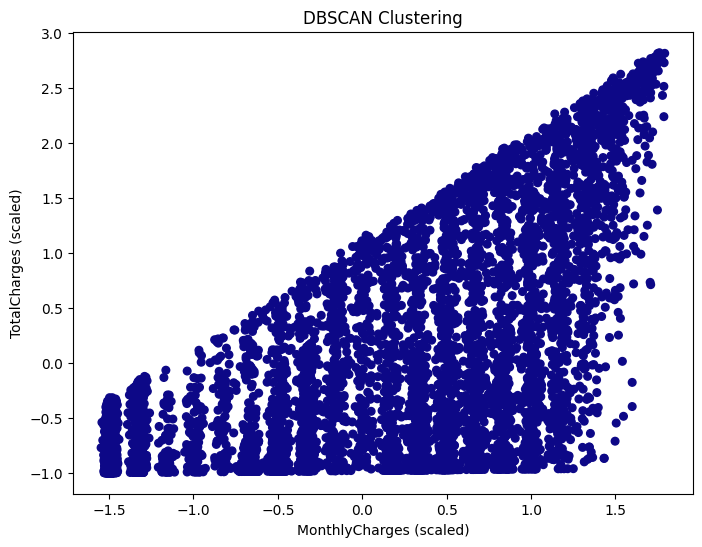

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("Customer_Churn.csv")

# Select features (example: MonthlyCharges, TotalCharges)
X = df[['MonthlyCharges', 'TotalCharges']].copy()
X['TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce')
X = X.dropna()

# Scale features (important for distance-based algorithms)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)  # tune these values
labels = dbscan.fit_predict(X_scaled)

# Add cluster labels to DataFrame
X['Cluster'] = labels

# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap='plasma', s=30)
plt.xlabel("MonthlyCharges (scaled)")
plt.ylabel("TotalCharges (scaled)")
plt.title("DBSCAN Clustering")
plt.show()

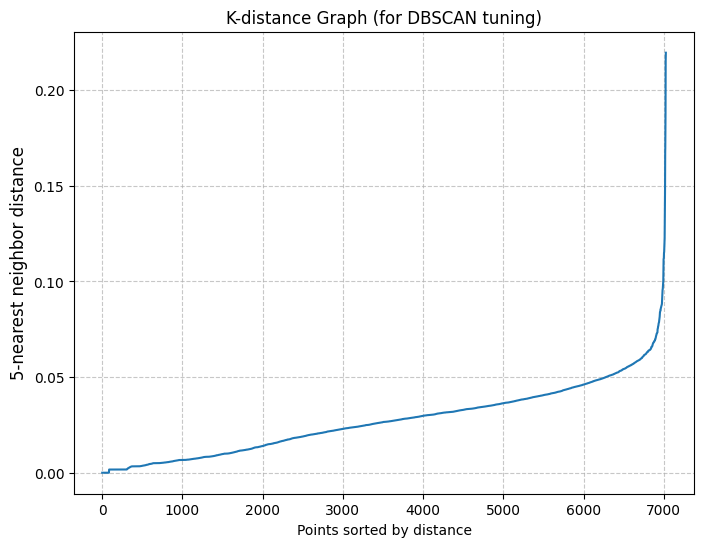

In [2]:
# let’s build the K‑distance graph for DBSCAN. This graph helps you visually choose the right eps value by plotting the distance to the 
# k‑nearest neighbor for each point. 
# The “elbow” in the curve suggests a good cutoff.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# Assume X_scaled is your standardized feature matrix
# Example: MonthlyCharges and TotalCharges scaled
# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# Step 1: Fit Nearest Neighbors
k = 5   # usually equal to min_samples
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Step 2: Sort distances of the k-th nearest neighbor
distances = np.sort(distances[:, k-1])

# Step 3: Plot K-distance graph
plt.figure(figsize=(8,6))
plt.plot(distances)
plt.title("K-distance Graph (for DBSCAN tuning)", fontsize=12)
plt.xlabel("Points sorted by distance", fontsize=10)
plt.ylabel(f"{k}-nearest neighbor distance", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

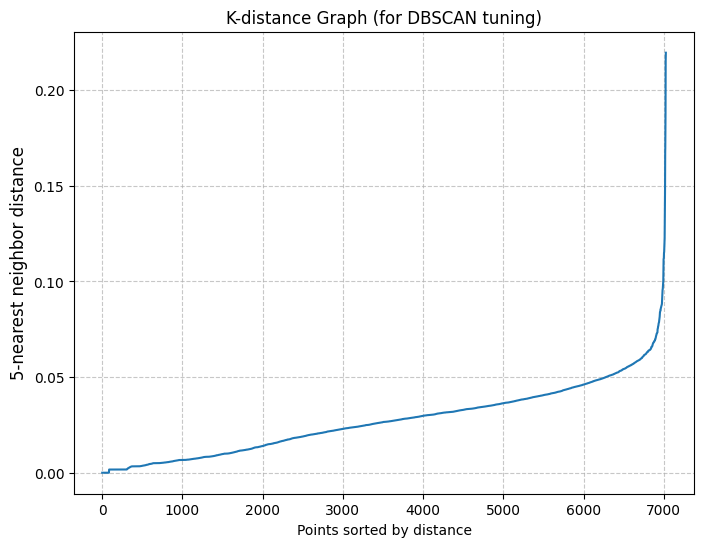

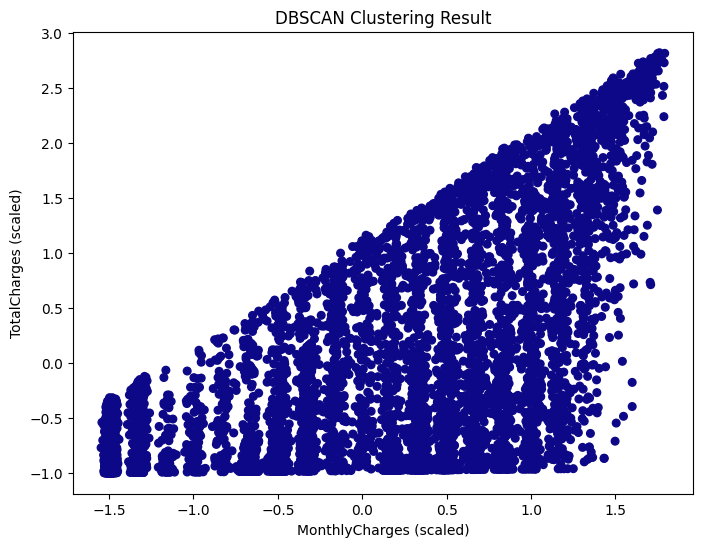

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# Load dataset
df = pd.read_csv("Customer_Churn.csv")

# Select features
X = df[['MonthlyCharges', 'TotalCharges']].copy()
X['TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce')
X = X.dropna()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 1: K-distance graph
k = 5   # usually equal to min_samples
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, k-1])

plt.figure(figsize=(8,6))
plt.plot(distances)
plt.title("K-distance Graph (for DBSCAN tuning)", fontsize=12)
plt.xlabel("Points sorted by distance", fontsize=10)
plt.ylabel(f"{k}-nearest neighbor distance", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Step 2: Apply DBSCAN with chosen eps (example: 0.6)
dbscan = DBSCAN(eps=0.6, min_samples=k)
labels = dbscan.fit_predict(X_scaled)

# Step 3: Scatter plot of clusters
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap='plasma', s=30)
plt.xlabel("MonthlyCharges (scaled)")
plt.ylabel("TotalCharges (scaled)")
plt.title("DBSCAN Clustering Result")
plt.show()

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Load dataset
df = pd.read_csv("Blobs.csv", header=None)
X = df.values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

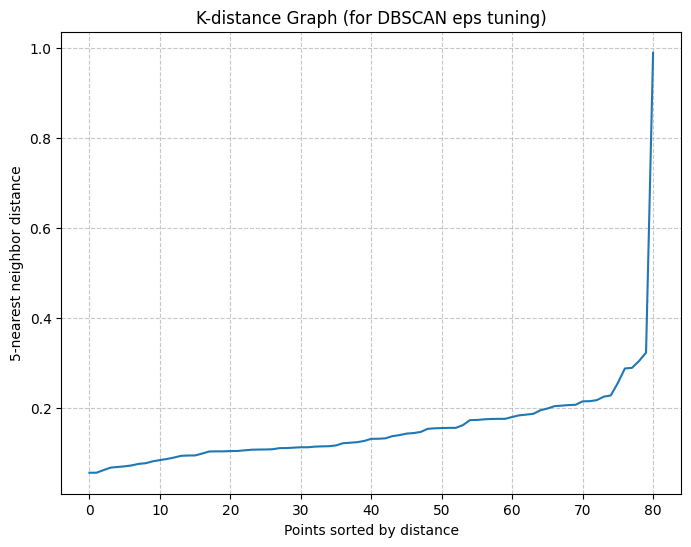

In [9]:
# Before applying DBSCAN, you need to estimate two key parameters — eps (neighborhood radius) and min_samples (minimum points to form a dense region).

# Use the K‑Distance Graph to Find eps

from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

k = 5  # often equal to min_samples
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Sort distances of the k-th nearest neighbor
distances = np.sort(distances[:, k-1])

plt.figure(figsize=(8,6))
plt.plot(distances)
plt.title("K-distance Graph (for DBSCAN eps tuning)")
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{k}-nearest neighbor distance")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Interpretation:

# The “elbow” point (where the curve sharply rises) ≈ good eps value. Example: if the elbow is around 0.6, use eps=0.6.

# Choose min_samples
# A common rule of thumb:   \text{min_samples} = 2 \times \text{number of features}
# For your dataset (2 features):  min_samples = 4 or 5.

In [10]:
# Apply DBSCAN
dbscan = DBSCAN(eps=0.6, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

In [11]:
# After applying DBSCAN, compute the Silhouette Score to confirm cluster quality:

from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled[labels != -1], labels[labels != -1])
print("Silhouette Score:", score)

Silhouette Score: 0.8016502768282653


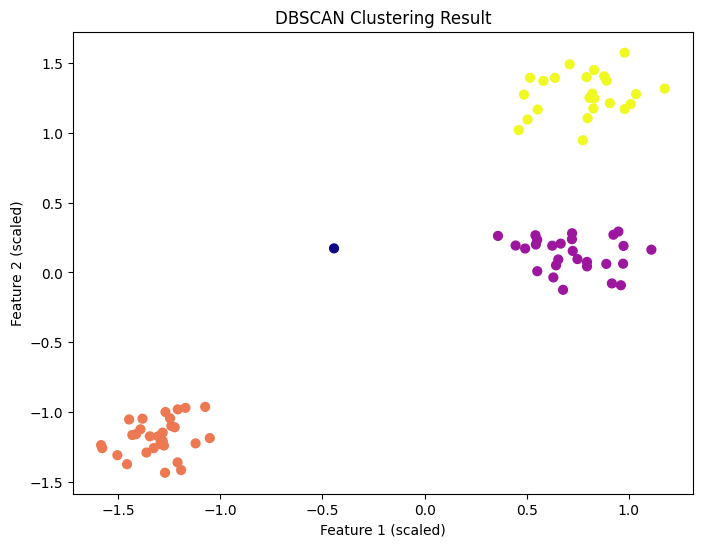

In [13]:
# Plot clusters
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap='plasma', s=40)
plt.title("DBSCAN Clustering Result")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.show()

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
Explained Variance Ratio:
[0.72962445 0.22850762]
Number of Clusters: 2
Silhouette Score: 0.558


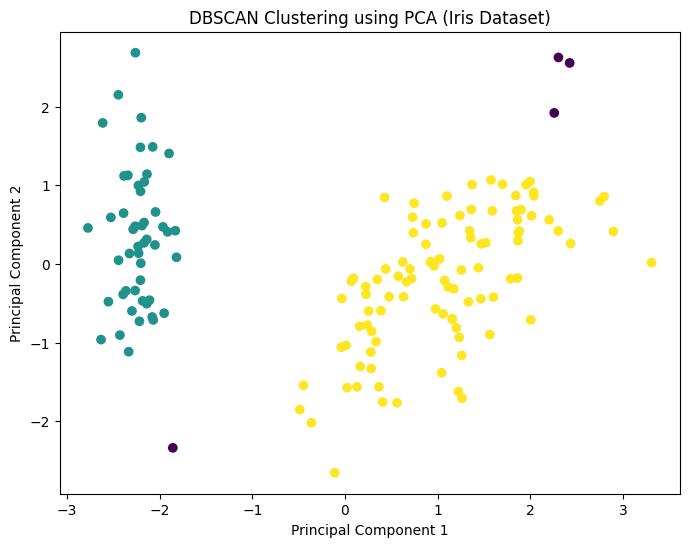

Cluster
-1     4
 0    49
 1    97
Name: count, dtype: int64


In [8]:
# DBSCAN is an unsupervised machine learning clustering algorithm that groups data points based on density.
# Unlike K-Means, you do not need to specify the number of clusters beforehand.
# It can also detect outliers (noise).


# ==========================
# Import Libraries
# ==========================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# ==========================
# Load Iris Dataset
# ==========================

iris = load_iris()

X = iris.data

# Create DataFrame (optional)

df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

print(df.head())

# ==========================
# Standardize the Data
# ==========================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ==========================
# PCA (Reduce to 2 dimensions)
# ==========================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:")

print(pca.explained_variance_ratio_)

# ==========================
# Apply DBSCAN
# ==========================

dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

clusters = dbscan.fit_predict(X_pca)

# Add clusters to dataframe

df["Cluster"] = clusters

# ==========================
# Number of clusters
# ==========================

print("Number of Clusters:", n_clusters)

# ==========================
# Silhouette Score
# ==========================

score = silhouette_score(
        X_pca,
        clusters
    )

print("Silhouette Score:", round(score,3))

# ==========================
# Visualize Clusters
# ==========================

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("DBSCAN Clustering using PCA (Iris Dataset)")

plt.show()

# ==========================
# Cluster counts
# ==========================

print(df["Cluster"].value_counts().sort_index())